 # 9장 식료품 구매에 어떤 연관성이 있을까?

In [1]:
# 경고 방지 위해 시간 설정
from datetime import datetime, timezone
now_utc = datetime.now(timezone.utc)

## **1. 데이터 수집하기**

식료품 데이터 셋 수집하기:
https://www.kaggle.com/datasets/heeraldedhia/groceries-dataset?select=Groceries_dataset.csv

# 1.1 파일 업로드하기

In [2]:
# 1.1 파일 업로드하기
from google.colab import files
uploaded = files.upload()

Saving Groceries_dataset.csv to Groceries_dataset.csv


In [3]:
# 1.2 데이터프레임 생성하기
import pandas as pd
df = pd.read_csv('/content/Groceries_dataset.csv')
df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


## **2. 탐색적 데이터 분석 및 전처리하기**

# 2.1 데이터 살펴보기

In [4]:
#2.1 데이터 살펴보기
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Member_number    38765 non-null  int64 
 1   Date             38765 non-null  object
 2   itemDescription  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB



 결측치 확인하기

In [5]:
df.isnull().sum()

,0
Member_number,0
Date,0
itemDescription,0


#2.2 빈도수 시각화하기

In [6]:
#2.2 빈도수 시각화하기
df['itemDescription'].value_counts()

,count
itemDescription,
whole milk,2502
other vegetables,1898
rolls/buns,1716
soda,1514
yogurt,1334
...,...
rubbing alcohol,5
bags,4
baby cosmetics,3


<Axes: xlabel='itemDescription'>

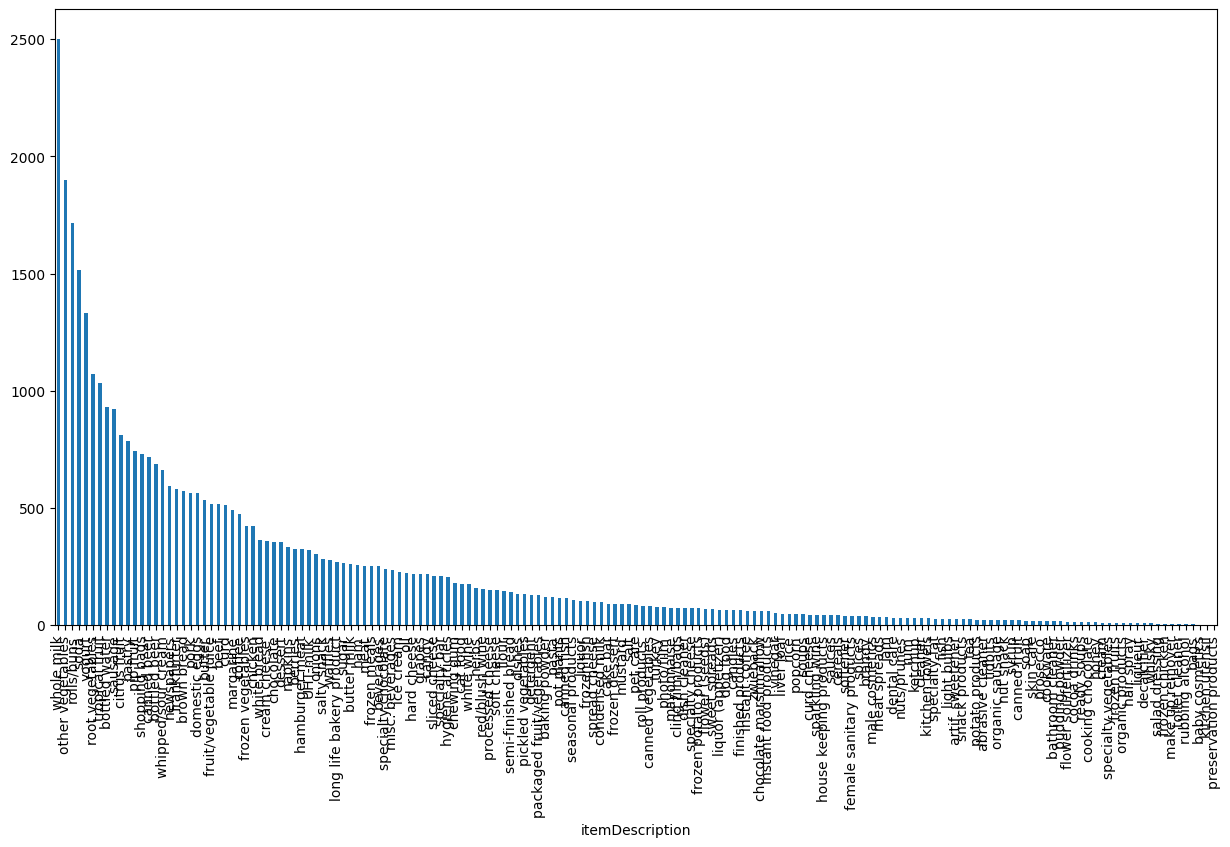

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15,8))
df['itemDescription'].value_counts().plot(kind='bar')

#2.3 연관 분석을 위한 트랜잭션 데이터 생성하기




# (1) 원-핫인 코딩하기

In [8]:
# 구매 품목 원-핫 인코딩하기
one_hot = pd.get_dummies(df['itemDescription'])
one_hot

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38760,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
38761,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
38762,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
38763,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


# (2) 고객번호, 날짜와 원핫 인코딩 항목 결합하기

In [9]:
df_combined = df[['Member_number', 'Date']].join(one_hot)
df_combined.head()

,Member_number,Date,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,1808,21-07-2015,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2552,05-01-2015,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,2300,19-09-2015,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1187,12-12-2015,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,3037,01-02-2015,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


# (3) 날짜별, 고객별로 그룹화하여 트랜잭션 생성하기

In [10]:
# 동일 고객, 동일 날짜의 구매 건을 하나의 '장바구니'로 묶고 구매 여부(0, 1)만 남깁니다.
transaction = df_combined.groupby(['Member_number', 'Date']).sum()
transaction[transaction >= 1] = 1
transaction

Instant food products  UHT-milk  abrasive cleaner  \
Member_number Date                                                            
1000          15-03-2015                      0         0                 0   
              24-06-2014                      0         0                 0   
              24-07-2015                      0         0                 0   
              25-11-2015                      0         0                 0   
              27-05-2015                      0         0                 0   
...                                         ...       ...               ...   
4999          24-01-2015                      0         0                 0   
              26-12-2015                      0         0                 0   
5000          09-03-2014                      0         0                 0   
              10-02-2015                      0         0                 0   
              16-11-2014                      0         0                 0   

                          artif. sweetener  baby cosmetics  bags  \
Member_number Date                                                 
1000          15-03-2015                 0               0     0   
              24-06-2014                 0               0     0   
              24-07-2015                 0               0     0   
              25-11-2015                 0               0     0   
              27-05-2015                 0               0     0   
...                                    ...             ...   ...   
4999          24-01-2015                 0               0     0   
              26-12-2015                 0               0     0   
5000          09-03-2014                 0               0     0   
              10-02-2015                 0               0     0   
              16-11-2014                 0               0     0   

                          baking powder  bathroom cleaner  beef  berries  ...  \
Member_number Date                                                        ...   
1000          15-03-2015              0                 0     0        0  ...   
              24-06-2014              0                 0     0        0  ...   
              24-07-2015              0                 0     0        0  ...   
              25-11-2015              0                 0     0        0  ...   
              27-05-2015              0                 0     0        0  ...   
...                                 ...               ...   ...      ...  ...   
4999          24-01-2015              0                 0     0        1  ...   
              26-12-2015              0                 0     0        0  ...   
5000          09-03-2014              0                 0     0        0  ...   
              10-02-2015              0                 0     0        0  ...   
              16-11-2014              0                 0     0        0  ...   

                          turkey  vinegar  waffles  whipped/sour cream  \
Member_number Date                                                       
1000          15-03-2015       0        0        0                   0   
              24-06-2014       0        0        0                   0   
              24-07-2015       0        0        0                   0   
              25-11-2015       0        0        0                   0   
              27-05-2015       0        0        0                   0   
...                          ...      ...      ...                 ...   
4999          24-01-2015       0        0        0                   0   
              26-12-2015       0        0        0                   0   
5000          09-03-2014       0        0        0                   0   
              10-02-2015       0        0        0                   0   
              16-11-2014       0        0        0                   0   

                          whisky  white bread  white wine  whole milk  yogurt  \
Member_number D

In [11]:
#트랜잭션 통계확인하기
transaction.describe()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
count,14963.000000,14963.000000,14963.000000,14963.000000,14963.000000,14963.000000,14963.000000,14963.000000,14963.000000,14963.000000,...,14963.000000,14963.000000,14963.000000,14963.000000,14963.000000,14963.000000,14963.000000,14963.000000,14963.000000,14963.000000
mean,0.004010,0.021386,0.001470,0.001938,0.000200,0.000267,0.008087,0.001136,0.033950,0.021787,...,0.005347,0.003408,0.018512,0.043708,0.000535,0.023993,0.011696,0.157923,0.085879,0.004010
std,0.063199,0.144672,0.038317,0.043983,0.014159,0.016348,0.089564,0.033689,0.181108,0.145993,...,0.072927,0.058284,0.134799,0.204451,0.023117,0.153031,0.107515,0.364681,0.280194,0.063199
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [12]:
# 분석을 위한 인덱스 재설정
transaction_final = transaction.reset_index().drop(['Member_number', 'Date'], axis=1)
transaction_final

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14958,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
14959,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14960,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14961,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


(5) 트랜젝션 데이터 파일로 저장하기

In [13]:
transaction_final.to_csv('groceries_transaction.csv')   # 트랜잭션 데이터 파일로 저장하기

In [14]:
import warnings
# DeprecationWarning(앞으로 없어질 기능에 대한 경고)만 무시하기
warnings.filterwarnings('ignore', category=DeprecationWarning)

#3. 연관 분석하기



In [18]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
# 연관분석을 위한 라이브러리 추가하기
from mlxtend.frequent_patterns import fpgrowth, association_rules

3.1 빈발 항목 집합 구하기

In [20]:
frequent_itemsets=fpgrowth(transaction_final, min_support=0.01, max_len=3, use_colnames=True)
frequent_itemsets.sort_values(by=['support'], ascending=True).head(10)

,support,itemsets
52,0.010025,(soft cheese)
47,0.010158,(processed cheese)
26,0.010493,(red/blush wine)
37,0.010559,(herbs)
67,0.010559,"(rolls/buns, other vegetables)"
64,0.011161,"(whole milk, yogurt)"
65,0.011629,"(whole milk, soda)"
35,0.011696,(white wine)
62,0.011829,(cat food)
63,0.012030,(chewing gum)


In [21]:
frequent_itemsets.sort_values(by=['support'], ascending=True).tail(10)

,support,itemsets
43,0.053131,(citrus fruit)
2,0.060349,(sausage)
29,0.060683,(bottled water)
18,0.067767,(tropical fruit)
22,0.069572,(root vegetables)
1,0.085879,(yogurt)
8,0.097106,(soda)
11,0.110005,(rolls/buns)
15,0.122101,(other vegetables)
0,0.157923,(whole milk)


In [22]:
frequent_itemsets.shape

(69, 2)

In [24]:
frequent_itemsets=fpgrowth(transaction_final, min_support=0.001, max_len=3, use_colnames=True)
frequent_itemsets.sort_values(by=['support'], ascending=True).head(10)

,support,itemsets
749,0.001002,"(rolls/buns, seasonal products)"
747,0.001002,"(chewing gum, soda)"
742,0.001002,"(cat food, tropical fruit)"
703,0.001002,"(citrus fruit, cream cheese )"
705,0.001002,"(frankfurter, cream cheese )"
629,0.001002,"(meat, soda)"
644,0.001002,"(root vegetables, hard cheese)"
666,0.001002,"(rolls/buns, soft cheese)"
564,0.001002,"(root vegetables, UHT-milk)"
552,0.001002,"(canned beer, coffee)"


In [25]:
frequent_itemsets.sort_values(by=['support'], ascending=True).tail(10)

,support,itemsets
64,0.053131,(citrus fruit)
2,0.060349,(sausage)
37,0.060683,(bottled water)
20,0.067767,(tropical fruit)
24,0.069572,(root vegetables)
1,0.085879,(yogurt)
9,0.097106,(soda)
13,0.110005,(rolls/buns)
17,0.122101,(other vegetables)
0,0.157923,(whole milk)


In [26]:
frequent_itemsets.shape

(750, 2)

3.2 연관 규칙 찾기

In [27]:
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules.sort_values(by=['lift'], ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
12,"(whole milk, yogurt)",(sausage),0.011161,0.060349,0.001470,0.131737,2.182917,1.0,7.967480e-04,1.082219,0.548014,0.020992,0.075973,0.078050
13,(sausage),"(whole milk, yogurt)",0.060349,0.011161,0.001470,0.024363,2.182917,1.0,7.967480e-04,1.013532,0.576701,0.020992,0.013351,0.078050
10,"(sausage, whole milk)",(yogurt),0.008955,0.085879,0.001470,0.164179,1.911760,1.0,7.012151e-04,1.093681,0.481231,0.015748,0.085657,0.090650
15,(yogurt),"(sausage, whole milk)",0.085879,0.008955,0.001470,0.017121,1.911760,1.0,7.012151e-04,1.008307,0.521727,0.015748,0.008239,0.090650
95,(citrus fruit),(specialty chocolate),0.053131,0.015973,0.001403,0.026415,1.653762,1.0,5.548137e-04,1.010726,0.417500,0.020731,0.010612,0.057141
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168,(grapes),(soda),0.014436,0.097106,0.001403,0.097222,1.001195,1.0,1.674919e-06,1.000129,0.001211,0.012743,0.000129,0.055838
58,(citrus fruit),(beef),0.053131,0.033950,0.001804,0.033962,1.000349,1.0,6.297697e-07,1.000012,0.000369,0.021160,0.000012,0.043556
59,(beef),(citrus fruit),0.033950,0.053131,0.001804,0.053150,1.000349,1.0,6.297697e-07,1.000020,0.000361,0.021160,0.000020,0.043556
201,(fruit/vegetable juice),(rolls/buns),0.034017,0.110005,0.003743,0.110020,1.000136,1.0,5.091755e-07,1.000017,0.000141,0.026679,0.000017,0.072021


연관규칙 간단하게 출력하기

In [28]:
fp_rules=rules.loc[:, ['antecedents','consequents','support','confidence','lift']]
fp_rules.sort_values(by=['lift'], ascending=False).head(10)

,antecedents,consequents,support,confidence,lift
12,"(whole milk, yogurt)",(sausage),0.001470,0.131737,2.182917
13,(sausage),"(whole milk, yogurt)",0.001470,0.024363,2.182917
10,"(sausage, whole milk)",(yogurt),0.001470,0.164179,1.911760
15,(yogurt),"(sausage, whole milk)",0.001470,0.017121,1.911760
95,(citrus fruit),(specialty chocolate),0.001403,0.026415,1.653762
94,(specialty chocolate),(citrus fruit),0.001403,0.087866,1.653762
11,"(sausage, yogurt)",(whole milk),0.001470,0.255814,1.619866
14,(whole milk),"(sausage, yogurt)",0.001470,0.009310,1.619866
134,(tropical fruit),(flour),0.001069,0.015779,1.617141
135,(flour),(tropical fruit),0.001069,0.109589,1.617141


3.3 연관규칙 시각화하기

(1) 지지도와 신뢰도의 분포 시각화하기

<Axes: xlabel='support', ylabel='confidence'>

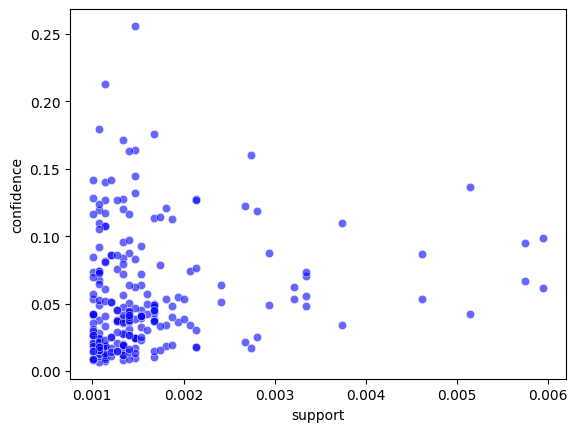

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(data=fp_rules, x='support', y='confidence', color='blue', alpha=0.6)

(2) 지지도와 향상도의 분포 시각화하기

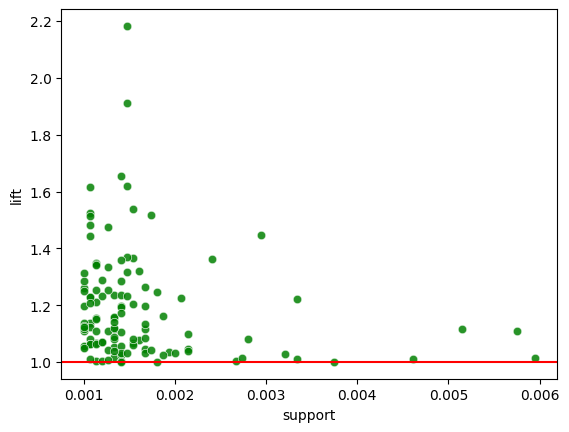

In [36]:
sns.scatterplot(data=fp_rules, x='support', y='lift', color='green', alpha=0.6)
plt.axhline(y=1, color='red')
plt.show()

 (3) 신뢰도와 향상도의 분포 시각화하기

<Axes: xlabel='confidence', ylabel='lift'>

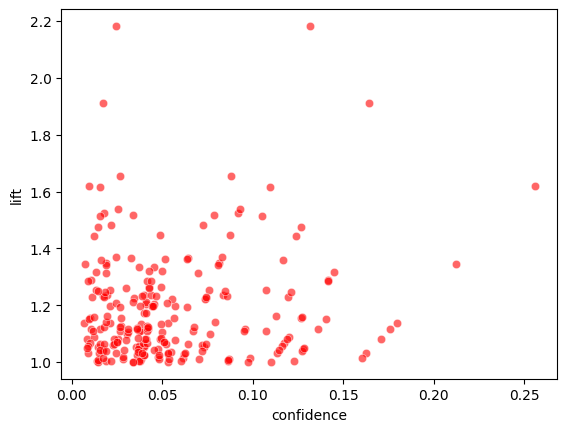

In [37]:
sns.scatterplot(data=fp_rules, x='confidence', y='lift', color='red', alpha=0.6)

(4) 연관규칙 그래프로 시각화하기

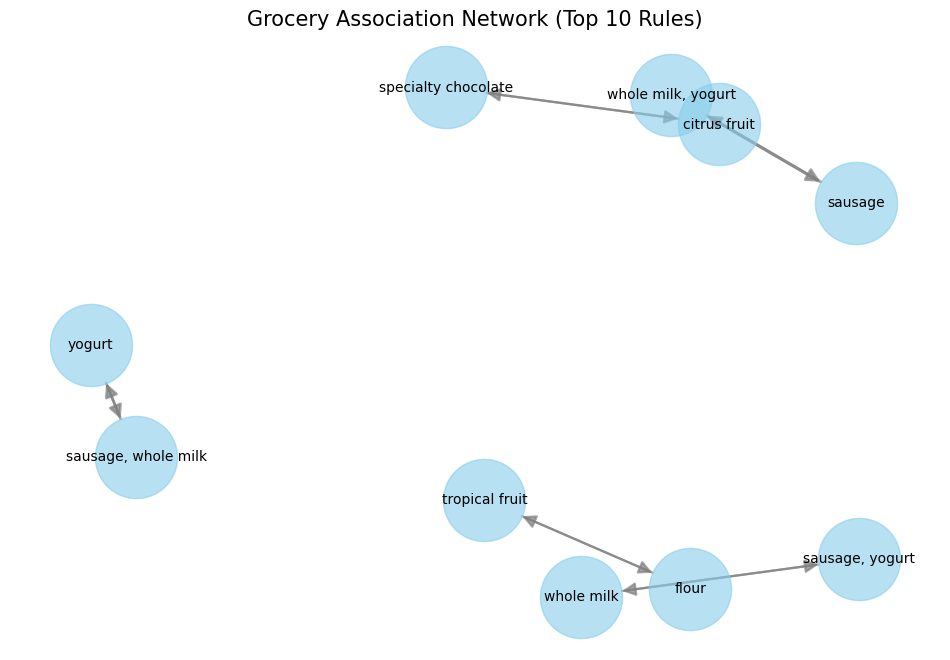

In [43]:
import networkx as nx

# 그래프 객체 생성
G = nx.DiGraph()

# 상위 규칙 데이터를 그래프에 추가
top_rules = fp_rules.sort_values(by='lift', ascending=False).head(10)

for _, row in top_rules.iterrows():
    ant = ', '.join(list(row['antecedents']))
    con = ', '.join(list(row['consequents']))
    G.add_edge(ant, con, weight=row['lift'])

# 레이아웃 설정
pos = nx.spring_layout(G, k=1.2, seed=42)

# 그래프 사이즈 설정하기
plt.figure(figsize=(12,8))

# [가장 아래] 동그라미
nx.draw_networkx_nodes(G, pos, node_size=3500, node_color='skyblue', alpha=0.6)

# [중간] 화살표 (원 위로 올라오도록 그리기)
nx.draw_networkx_edges(G, pos,
                       width=[d['weight'] for _, _, d in G.edges(data=True)],
                       edge_color='gray',
                       alpha=0.7,
                       arrowsize=20,
                       node_size=3500)

# [가장 위] 글자
nx.draw_networkx_labels(G, pos, font_size=10)

# 제목 출력
plt.title("Grocery Association Network (Top 10 Rules)", fontsize=15)
plt.axis('off')
plt.show()

#4. 연관 분석 활용하기

(1) 향상도 1초과하는 연관 규칙 출력하기

In [38]:
fp_rules[(fp_rules['lift']) >1 ].sort_values(by=['lift'], ascending=False)

,antecedents,consequents,support,confidence,lift
12,"(whole milk, yogurt)",(sausage),0.001470,0.131737,2.182917
13,(sausage),"(whole milk, yogurt)",0.001470,0.024363,2.182917
10,"(sausage, whole milk)",(yogurt),0.001470,0.164179,1.911760
15,(yogurt),"(sausage, whole milk)",0.001470,0.017121,1.911760
95,(citrus fruit),(specialty chocolate),0.001403,0.026415,1.653762
...,...,...,...,...,...
168,(grapes),(soda),0.001403,0.097222,1.001195
58,(citrus fruit),(beef),0.001804,0.033962,1.000349
59,(beef),(citrus fruit),0.001804,0.053150,1.000349
201,(fruit/vegetable juice),(rolls/buns),0.003743,0.110020,1.000136


(2) 관심 상품과 함께 구매하는 상품 출력하기

In [39]:
fp_rules[(fp_rules['antecedents']==frozenset({'rolls/buns'}))].sort_values(by = 'lift', ascending = False)

,antecedents,consequents,support,confidence,lift
182,(rolls/buns),(processed cheese),0.001470,0.013366,1.315734
116,(rolls/buns),(packaged fruit/vegetables),0.001203,0.010936,1.288421
238,(rolls/buns),(seasonal products),0.001002,0.009113,1.286395
113,(rolls/buns),(red/blush wine),0.001337,0.012151,1.158028
21,(rolls/buns),"(sausage, whole milk)",0.001136,0.010328,1.153275
4,(rolls/buns),"(whole milk, yogurt)",0.001337,0.012151,1.088685
109,(rolls/buns),(chocolate),0.002807,0.025516,1.081592
43,(rolls/buns),"(other vegetables, soda)",0.001136,0.010328,1.065785
103,(rolls/buns),(detergent),0.001002,0.009113,1.057037
228,(rolls/buns),(ice cream),0.001738,0.015796,1.041205
